In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY") 

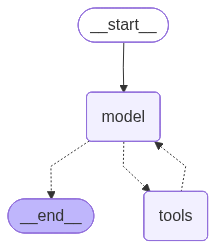

In [10]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
llm = init_chat_model(model='openai/gpt-oss-120b',temperature=0.4, model_provider='groq')

def get_weather(city:str):
    """Get the weather details"""
    return f"Today is sunny in {city}"

def get_order(order:str):
    """Get status of your order"""
    return f"Your {order} is in transit"

agent = create_agent(
    model=llm,
    tools=[get_weather,get_order],
    system_prompt="You are a helpful assistant"
)
agent

In [11]:
agent.invoke({"messages":"What is the weather in delhi?"})

{'messages': [HumanMessage(content='What is the weather in delhi?', additional_kwargs={}, response_metadata={}, id='fe813da2-b94b-4d6f-b59d-e9ddb2a63a90'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the weather in delhi?" We need to use the get_weather function with city "Delhi". Use function call.', 'tool_calls': [{'id': 'fc_0b428ce8-99e4-4440-89d2-f5f1abb23394', 'function': {'arguments': '{"city":"Delhi"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 156, 'total_tokens': 214, 'completion_time': 0.128492088, 'completion_tokens_details': {'reasoning_tokens': 31}, 'prompt_time': 0.006271295, 'prompt_tokens_details': None, 'queue_time': 0.05071934, 'total_time': 0.134763383}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_d29d1d1418', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run

In [13]:
agent.invoke({"messages":"Where is my margheritta pizza with order number 123kudos343"})

{'messages': [HumanMessage(content='Where is my margheritta pizza with order number 123kudos343', additional_kwargs={}, response_metadata={}, id='2f0f6d41-4c56-4db7-801d-35522f3b78b0'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "Where is my margheritta pizza with order number 123kudos343". We need to retrieve order status using get_order function. Provide order number. Use function.', 'tool_calls': [{'id': 'fc_a0191b3b-9c90-4c93-8ee6-a9fb2bdf463e', 'function': {'arguments': '{"order":"123kudos343"}', 'name': 'get_order'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 163, 'total_tokens': 233, 'completion_time': 0.156082826, 'completion_tokens_details': {'reasoning_tokens': 40}, 'prompt_time': 0.007145451, 'prompt_tokens_details': None, 'queue_time': 0.052275133, 'total_time': 0.163228277}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_626f3fc5e0', 'service_tier': 'on_demand', 'f

In [18]:
response = llm.stream("Write a 50 words paragraph on AI")
# print(response)
for chunk in response:
    print(chunk, end="|", flush=True)

content='' additional_kwargs={} response_metadata={'model_provider': 'groq'} id='lc_run--019da0e4-c6e9-7490-9a8d-7a96ad7aa712' tool_calls=[] invalid_tool_calls=[] tool_call_chunks=[]|content='' additional_kwargs={'reasoning_content': 'The'} response_metadata={'model_provider': 'groq'} id='lc_run--019da0e4-c6e9-7490-9a8d-7a96ad7aa712' tool_calls=[] invalid_tool_calls=[] tool_call_chunks=[]|content='' additional_kwargs={'reasoning_content': ' user'} response_metadata={'model_provider': 'groq'} id='lc_run--019da0e4-c6e9-7490-9a8d-7a96ad7aa712' tool_calls=[] invalid_tool_calls=[] tool_call_chunks=[]|content='' additional_kwargs={'reasoning_content': ' asks'} response_metadata={'model_provider': 'groq'} id='lc_run--019da0e4-c6e9-7490-9a8d-7a96ad7aa712' tool_calls=[] invalid_tool_calls=[] tool_call_chunks=[]|content='' additional_kwargs={'reasoning_content': ':'} response_metadata={'model_provider': 'groq'} id='lc_run--019da0e4-c6e9-7490-9a8d-7a96ad7aa712' tool_calls=[] invalid_tool_calls=[]

### Langchain tools
This gives you insight how the agent calls the tool internally.

In [20]:
from langchain.tools import tool

@tool
def get_weather_details(city: str) -> str:
    """Get weather details by providing city"""
    return f"Today is cloudy in {city}"

In [ ]:
model_with_tools = llm.bind_tools([get_weather_details])
response = model_with_tools.invoke("What is the weather in Chattisgarh?")
tool = response.tool_calls
tool

[{'name': 'get_weather_details',
  'args': {'city': 'Raipur, Chhattisgarh'},
  'id': 'fc_921b54e0-90d9-4ba6-98d0-a67432d99b39',
  'type': 'tool_call'}]

In [34]:
messages = [{"role": "user", "content":"What is the weather in Delhi?"}]
ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)

for tool_call in ai_msg.tool_calls:
    tool_msg = get_weather_details.invoke(tool_call)
    messages.append(tool_msg)

final_response = model_with_tools.invoke(messages)
print(messages)
print(final_response.content)

[{'role': 'user', 'content': 'What is the weather in Delhi?'}, AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks for weather in Delhi. We have function get_weather_details. We should call it.', 'tool_calls': [{'id': 'fc_560fee4b-4894-42fd-af76-4326801ff5e5', 'function': {'arguments': '{"city":"Delhi"}', 'name': 'get_weather_details'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 128, 'total_tokens': 176, 'completion_time': 0.101175472, 'completion_tokens_details': {'reasoning_tokens': 20}, 'prompt_time': 0.004926805, 'prompt_tokens_details': None, 'queue_time': 0.050789865, 'total_time': 0.106102277}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_626f3fc5e0', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019da168-abe3-74f0-8230-9de62207a6a3-0', tool_calls=[{'name': 'get_weather_details', 'args': {'city': 'Delhi'}, 'id': 'f